# Inspect emulators results

In [1]:
root = '/ceph/hpc/data/s25r06-05-users'

## Init

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import os
import emu_like.io as io
from emu_like.ffnn_emu import FFNNEmu

2025-10-15 13:52:12.155090: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 13:52:12.158964: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-15 13:52:12.169882: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1760529132.188136 1943056 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760529132.193603 1943056 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760529132.207585 1943056 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
class EmuData(object):

    def __init__(self, path_emu, root=root):
        self.name = path_emu
        self.emu = FFNNEmu()
        self.emu.load(os.path.join(root, path_emu), still_training=False)
        self.diff = None
        self.mean_diff = None
        pass

    def _scale_x(self, x):
        return self.emu.x_scaler.transform(x)

    def _scale_y(self, y):
        return self.emu.y_scaler.transform(y)

    def _inverse_scale_x(self, x):
        return self.emu.x_scaler.inverse_transform(x)

    def _inverse_scale_y(self, y):
        return self.emu.y_scaler.inverse_transform(y)

    def _pca_x(self, x):
        return self.emu.x_pca.transform(x)

    def _pca_y(self, y):
        return self.emu.y_pca.transform(y)

    def _inverse_pca_x(self, x):
        return self.emu.x_pca.inverse_transform(x)

    def _inverse_pca_y(self, y):
        return self.emu.y_pca.inverse_transform(y)

    def get_y_emu(self, x, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        From the emulator we get y that are potentially scaled and PCA
        applied. However, it is possible that just one or none of them
        are used. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot keep scaled units: y is already unscaled.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        # 1) Adjust x
        # Adjust dimensions x array
        if x.ndim == 1:
            x = x[np.newaxis, :]
        # Scale x
        if self.emu.x_scaler is not None:
            x = self._scale_x(x)
        # PCA x
        if self.emu.x_pca is not None:
            x = self._pca_x(x)

        # 2) Emulate y
        result = self.emu.model(x, training=False).numpy()

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if has_pca and not want_pca:
            result = self._inverse_pca_y(result)

        # 5) Remove scaling
        if has_scaling and not want_scaling:
            result = self._inverse_scale_y(result)

        # 6) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_y_data(self, y, want_scaling=False, want_pca=False, select_pca_modes=None):
        """
        Postprocess the data to add/remove scaling and PCA. It works to provide
        a compatible output of get_y_emu. Input data are assumed to not be scaled and
        without PCA applied. Errors are implemented for incompatible requests:
        Arguments:
        - x (array): 1-2D array for the x that should be emulated;
        - want_scaling (bool, default: False): want the results scaled or in the original units;
        - want_pca (bool, default: False): want the results in PCA space or not;
        - select_pca_modes (list, default: None): if list select the listed modes in PCA space.
        """

        # Flags
        has_pca = self.emu.y_pca is not None
        has_scaling = self.emu.y_scaler is not None
        want_pca_selection = select_pca_modes is not None

        # Validate requested configuration
        if want_scaling and not has_scaling:
            raise ValueError('Cannot use scaled units: emulator has no scaling transform.')
        if want_pca and not has_pca:
            raise ValueError('Cannot request PCA output: emulator has no PCA transform.')
        if want_pca_selection and not has_pca:
            raise ValueError('Cannot select PCA modes: emulator has no PCA transform.')
        if want_pca and has_scaling and not want_scaling:
            raise ValueError('Cannot stay in PCA space while undoing scaling when PCA was built on scaled data.')

        result = y

        # 1) Scale
        if want_scaling:
            result = self._scale_y(result)

        # 2) PCA
        if want_pca or want_pca_selection:
            result = self._pca_y(result)

        # 3) Make selection
        if want_pca_selection:
            tmp = np.zeros_like(result)
            tmp[:, select_pca_modes] = result[:, select_pca_modes]
            result = tmp

        # 4) Remove PCA
        if want_pca_selection and not want_pca:
            # remove pca
            result = self._inverse_pca_y(result)

        # 5) Output the correct shape
        if want_pca and want_pca_selection:
            result = result[:, select_pca_modes]
        if len(result) == 1:
            result = result[0]

        return result

    def get_diff(self, x_emu, y_data, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        """
        Get the relative difference of emulated y and data.
        It uses get_y_emu and get_y_data and check for consistency.
        """

        if want_pca and select_pca_modes_emu != select_pca_modes_data:
            raise ValueError('You want incosistent dimensions. It is not possible to calculate the relative difference.')

        y_emu = self.get_y_emu(
            x_emu,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_emu)

        y_data = self.get_y_data(
            y_data,
            want_scaling=want_scaling,
            want_pca=want_pca,
            select_pca_modes=select_pca_modes_data)

        self.diff = y_emu/y_data - 1.
        return self.diff
    
    def get_mean_diff(self, x_emu=None, y_data=None, want_scaling=False, want_pca=False, select_pca_modes_emu=None, select_pca_modes_data=None):
        if x_emu is not None and y_data is not None:
            self.diff = self.get_diff(
                x_emu,
                y_data,
                want_scaling=want_scaling,
                want_pca=want_pca,
                select_pca_modes_emu=select_pca_modes_emu,
                select_pca_modes_data=select_pca_modes_data)

        self.mean_diff = np.mean(self.diff**2., axis=1)
        return self.mean_diff
    
    def get_sorting_idxs(self):
        if self.mean_diff is None:
            raise Exception('Calculate mean_diff first')
        return self.mean_diff.argsort()[::-1]

## Histograms

In [4]:
spectrum_type = 'cl'
spectrum = 'cl_TT_lensed'
dataset_ranges = ['thin', 'std', 'ext']

# Load data
x_data = {}
y_data = {}
for dr in dataset_ranges:
    path_dataset = os.path.join(root, 'lcdm/sample/{}_100_{}.fits'.format(spectrum_type, dr))
    dataset = io.FitsFile(path_dataset)
    x_data[dr] = dataset.get_data('x_data')
    y_data[dr] = dataset.get_data(spectrum)

In [5]:
paths_emu = [
    'lcdm/train/test_cl_1',
    'lcdm/train/test_cl_2',
    'lcdm/train/test_cl_3',
    'lcdm/train/test_cl_4',
    'lcdm/train/test_cl_5',
]

# Load emulators
emudata = {}
for path in paths_emu:
    emudata[path] = EmuData(path, root=root)

2025-10-15 13:52:24.507013: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


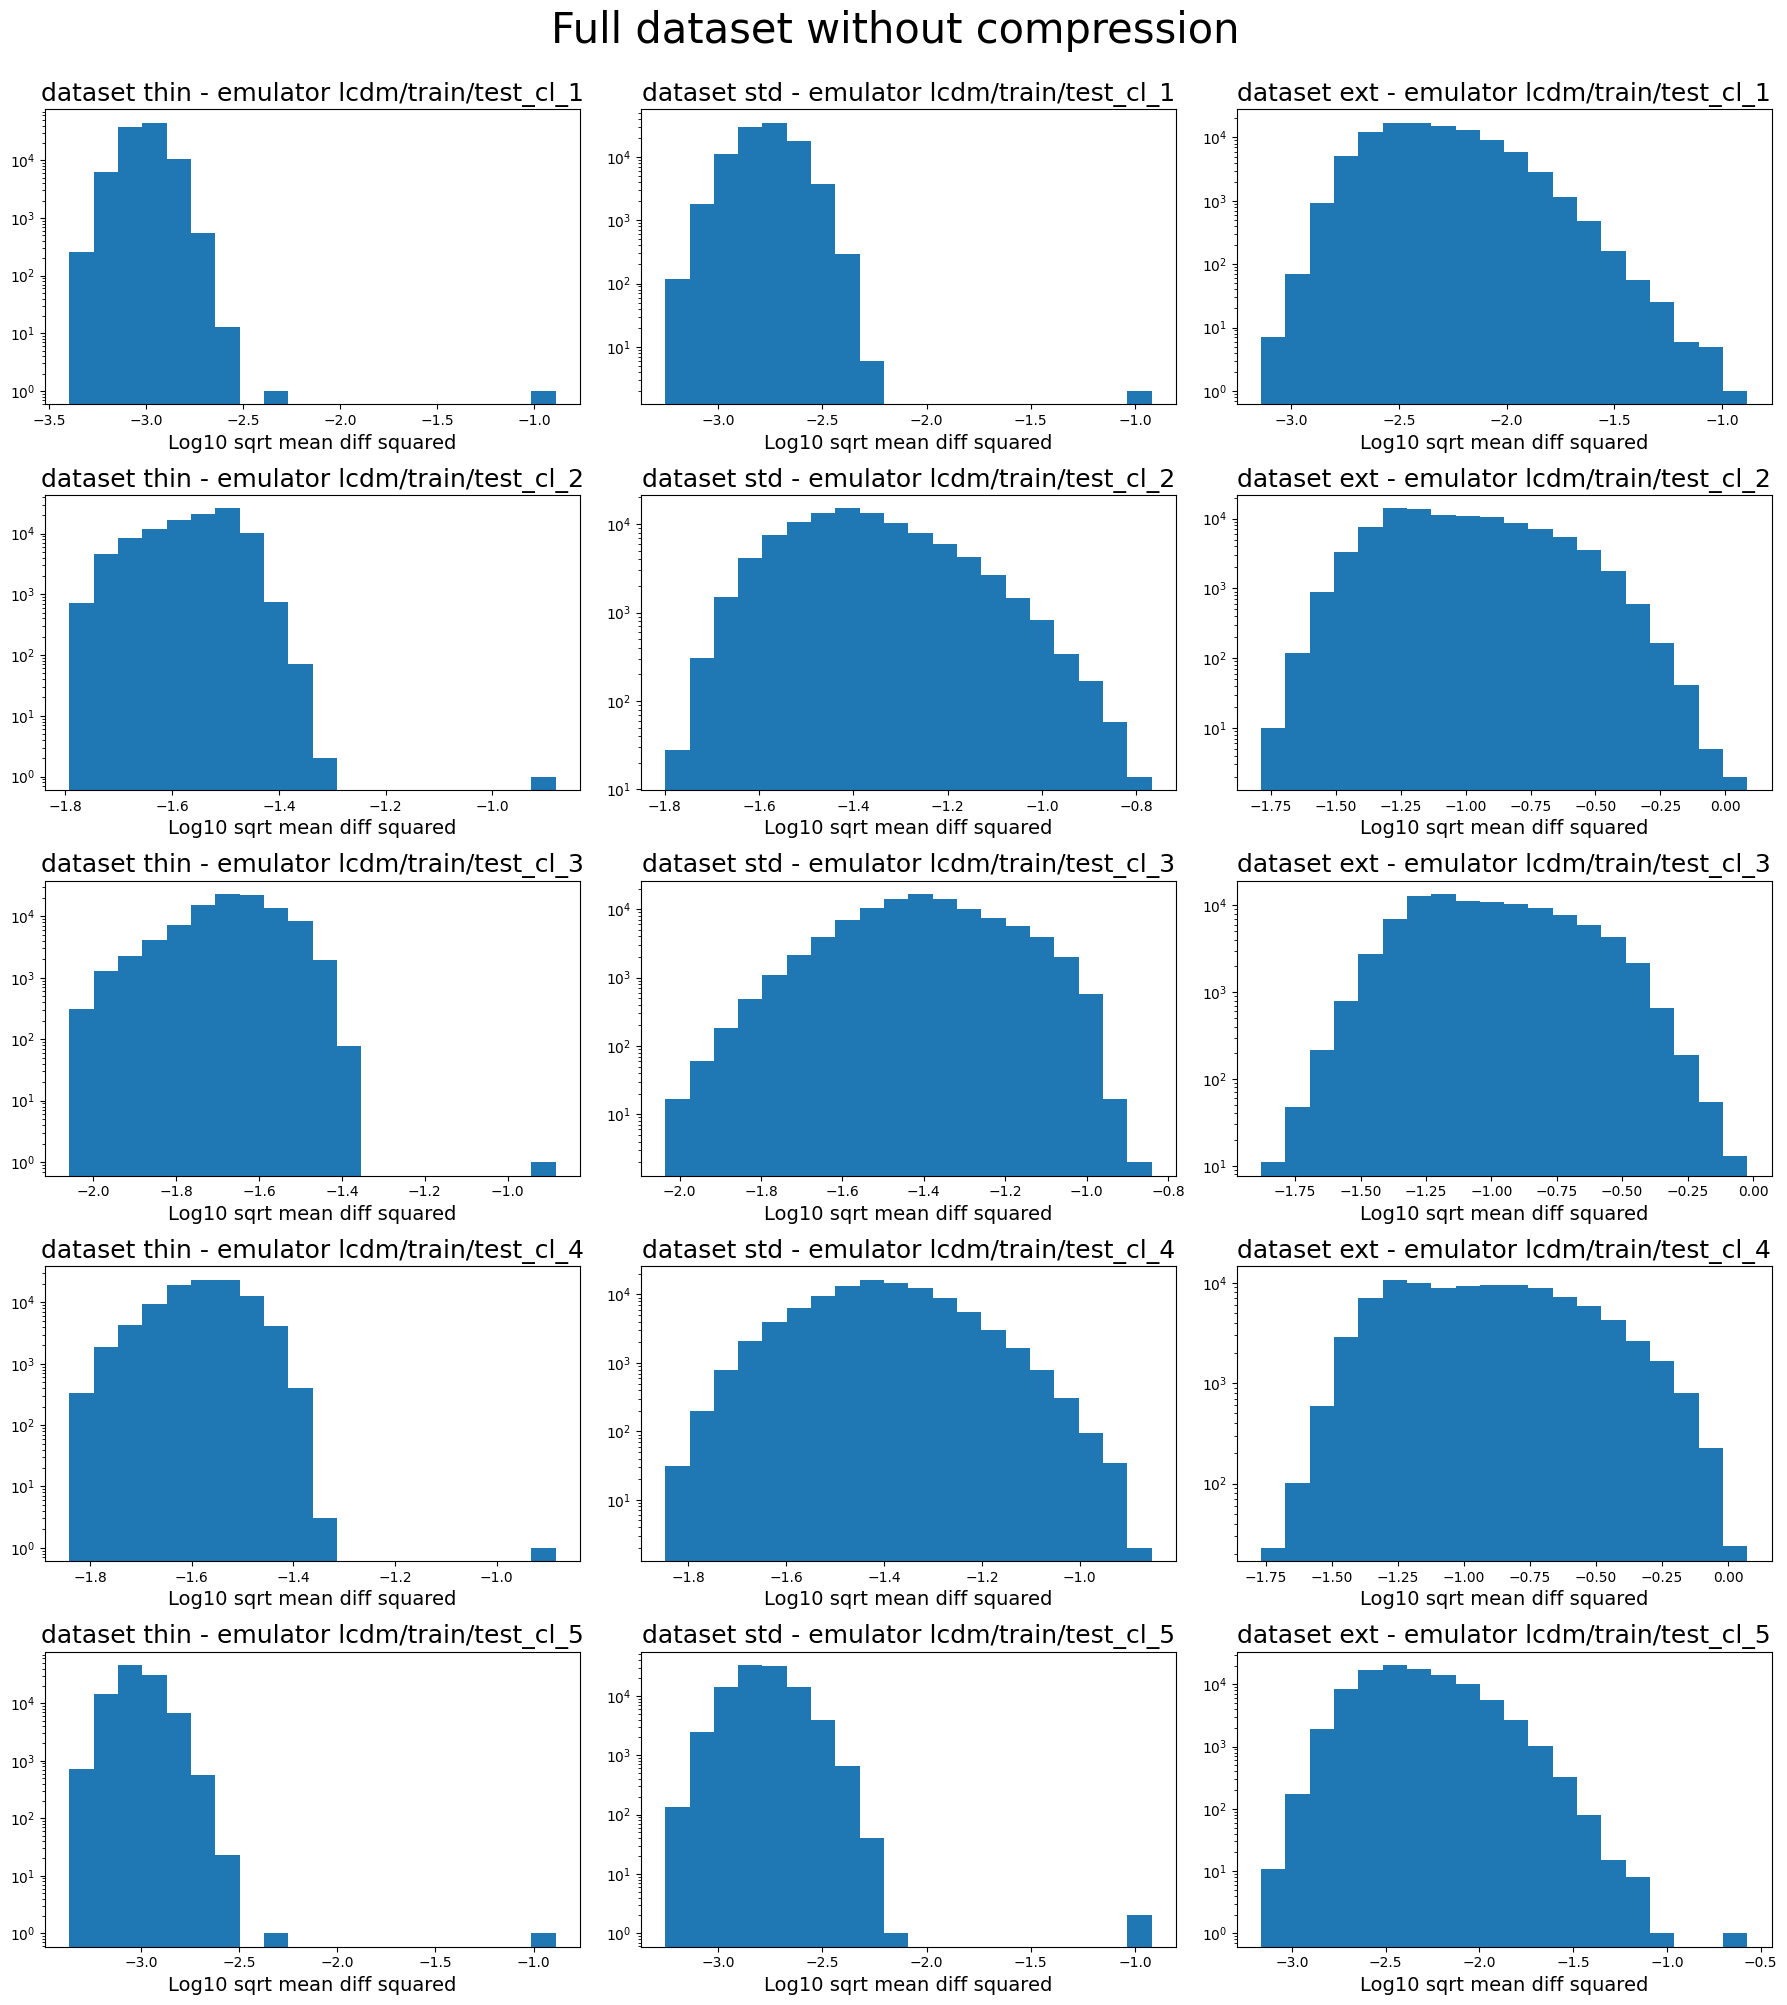

In [6]:
# Create figure
fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False)
fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

# Plot data in each subplot
for npath, path in enumerate(paths_emu):
    for ndt, dt in enumerate(dataset_ranges):
        mean_diff = emudata[path].get_mean_diff(
            x_emu=x_data[dt],
            y_data=y_data[dt],
            want_scaling=False,
            want_pca=False,
            select_pca_modes_emu=None,
            select_pca_modes_data=None)

        axs[npath, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[npath, ndt].set_title('dataset {} - emulator {}'.format(dt, path), fontsize=18)
        axs[npath, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

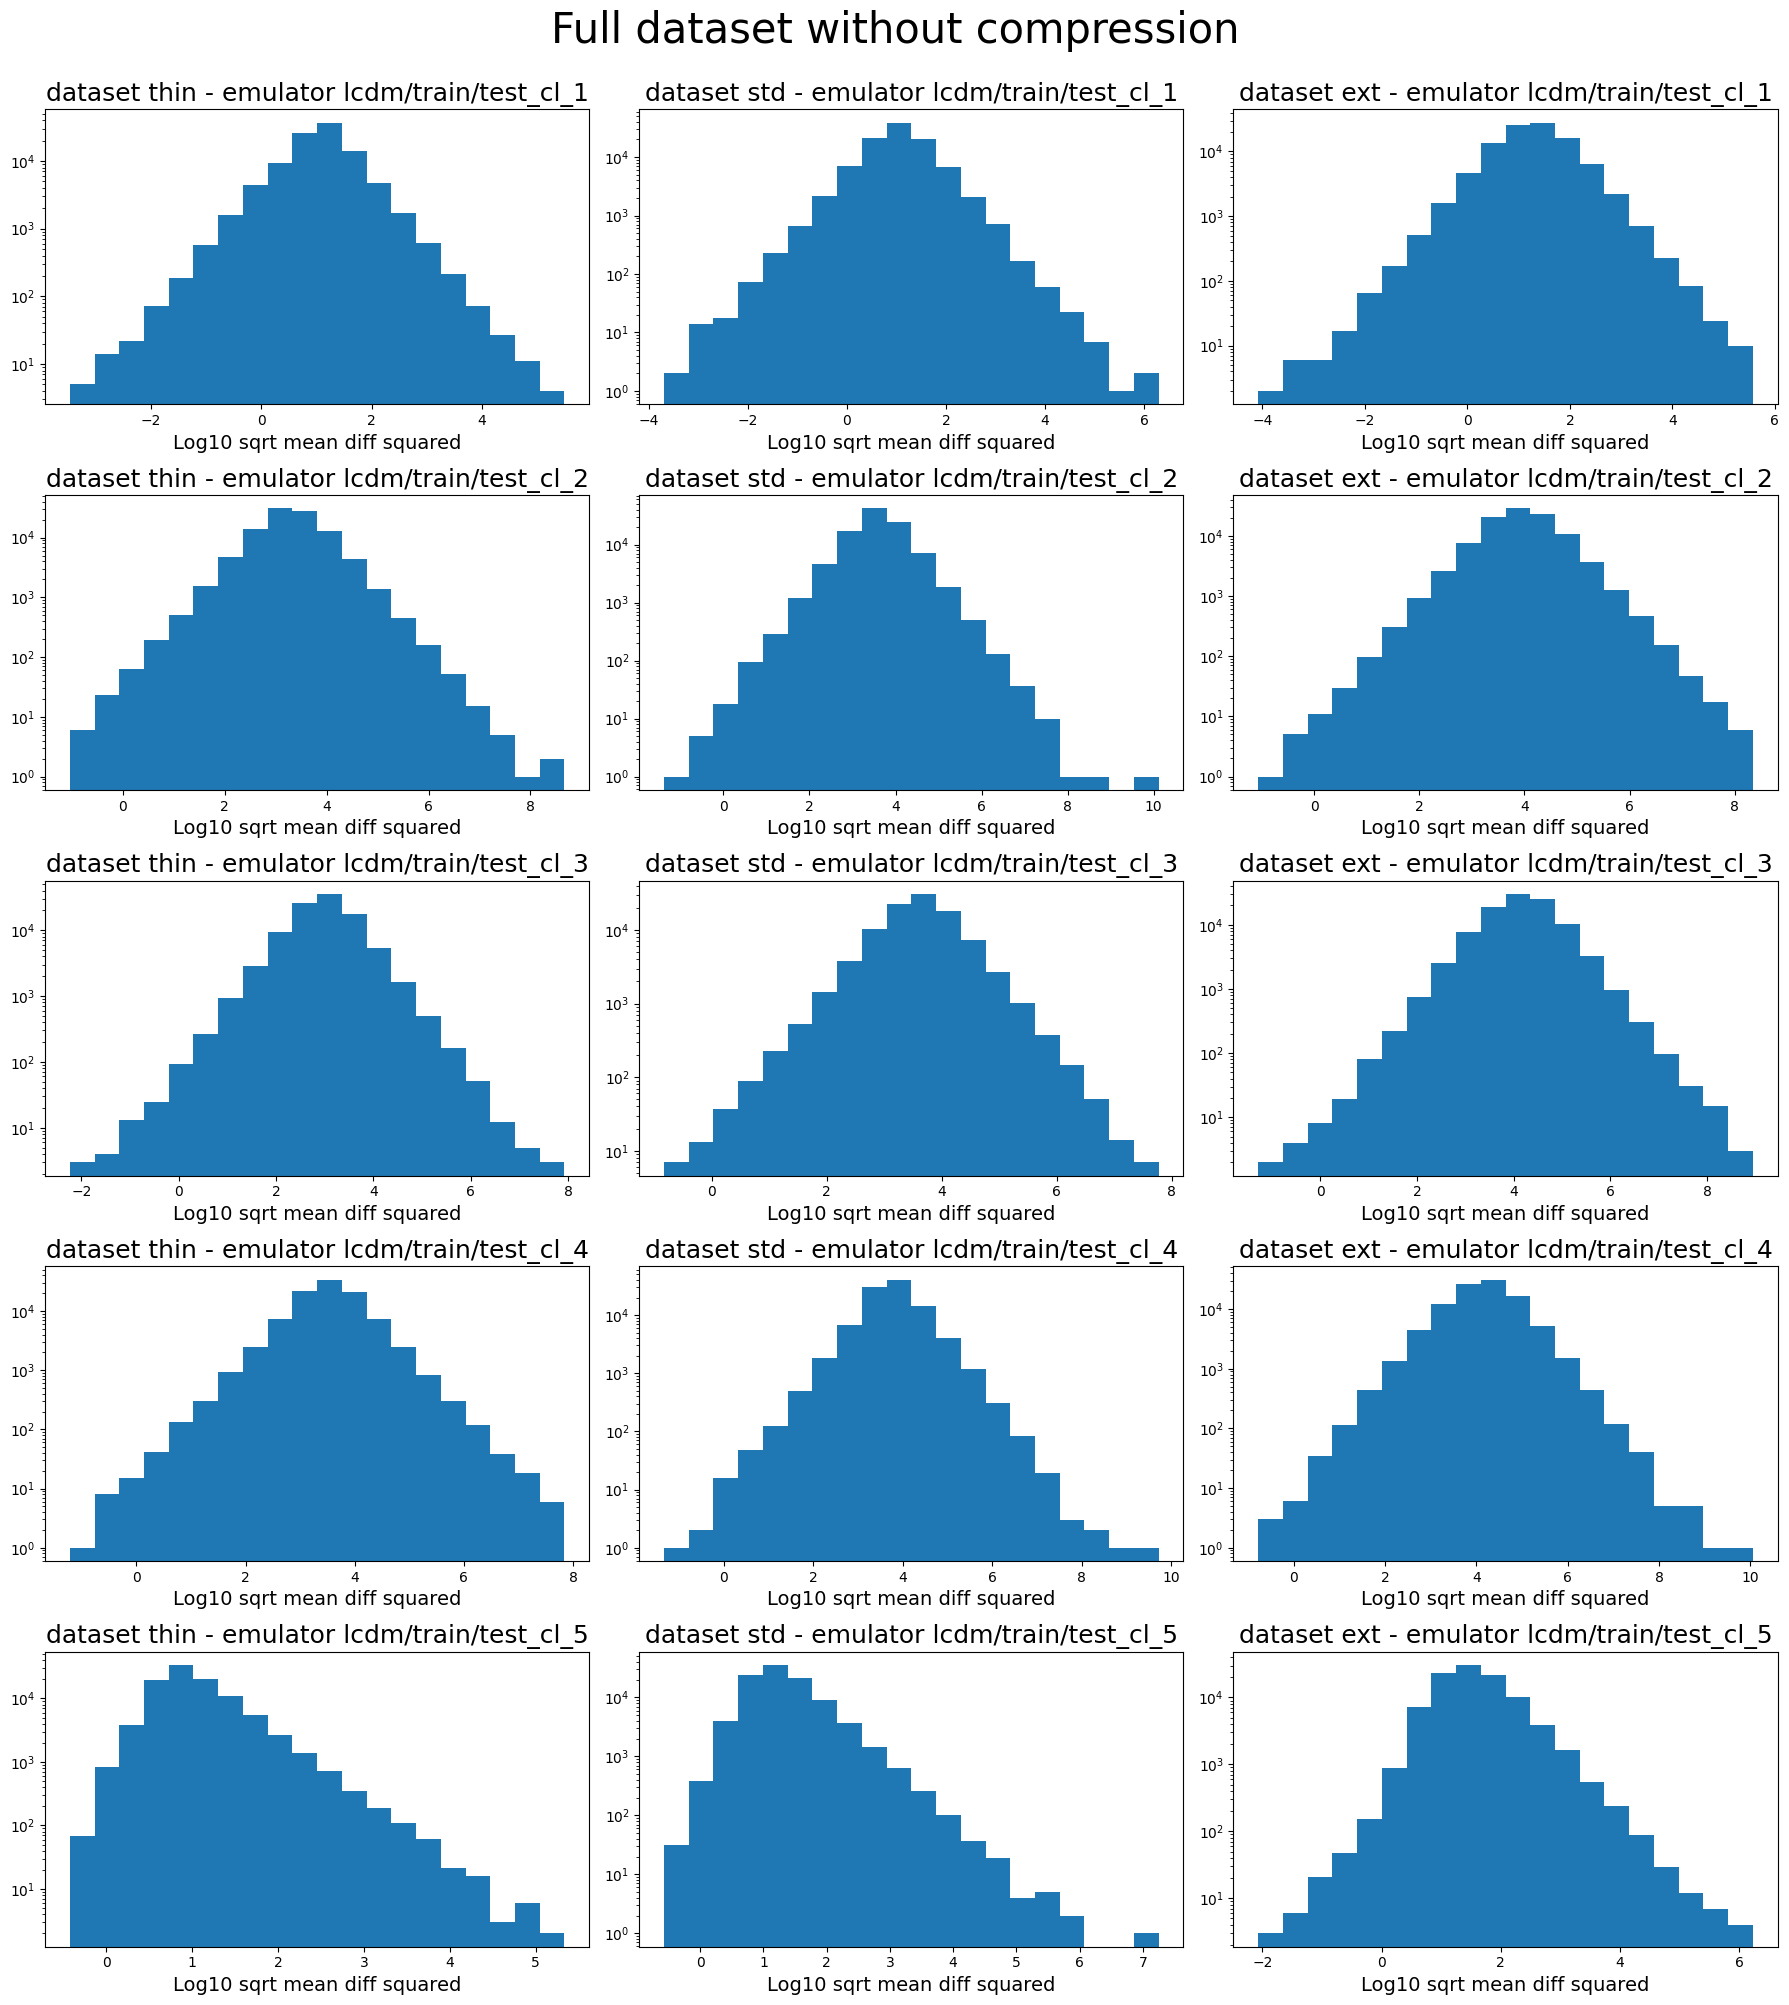

In [9]:
# Create figure
fig, axs = plt.subplots(len(paths_emu), len(dataset_ranges), figsize=(6*len(dataset_ranges), 4*len(paths_emu)), squeeze=False)
fig.suptitle('Full dataset without compression', fontsize=30, y=1.0)

# Plot data in each subplot
for npath, path in enumerate(paths_emu):
    for ndt, dt in enumerate(dataset_ranges):
        mean_diff = emudata[path].get_mean_diff(
            x_emu=x_data[dt],
            y_data=y_data[dt],
            want_scaling=True,
            want_pca=True,
            select_pca_modes_emu=[-1],
            select_pca_modes_data=[-1])

        axs[npath, ndt].hist(np.log10(np.sqrt(mean_diff)), log=True, bins=20)
        axs[npath, ndt].set_title('dataset {} - emulator {}'.format(dt, path), fontsize=18)
        axs[npath, ndt].set_xlabel('Log10 sqrt mean diff squared', fontsize=14)


# Adjust layout to prevent overlapping
plt.tight_layout()

# Show the plot
plt.show()

## Histograms

In [ ]:
nemu = 4
cosmo_param = 0
n_data = 4

# Sample data - list of curves and their parameters
curves = diff[nemu].diff[1:n_data]*100
parameters_all = diff[nemu].x[1:n_data, cosmo_param]
parameters = parameters_all  # Your curve-dependent parameters
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize parameters to [0,1] range for colormap
norm = mpl.colors.Normalize(vmin=min(parameters_all), vmax=max(parameters_all))
cmap = plt.cm.twilight_shifted

# Plot each curve with color based on parameter
for curve, param in zip(curves, parameters):
    color = cmap(norm(param))
    ax.plot(curve.T, color=color)
ax.set_xscale('log')

# Add colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Parameter Value')

plt.show()

In [ ]:
nemu = 4
cosmo_param = 0
n_data = 10

# Sample data - list of curves and their parameters
curves = diff[nemu].diff[-n_data:]*100
parameters_all = diff[nemu].x[-n_data:, cosmo_param]
parameters = parameters_all  # Your curve-dependent parameters
# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Normalize parameters to [0,1] range for colormap
norm = mpl.colors.Normalize(vmin=min(parameters_all), vmax=max(parameters_all))
cmap = plt.cm.twilight_shifted

# Plot each curve with color based on parameter
for curve, param in zip(curves, parameters):
    color = cmap(norm(param))
    ax.plot(curve.T, color=color)
ax.set_xscale('log')

# Add colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Parameter Value')

plt.show()